# 多元线性回归 —— 加州房价预测

使用**闭式解（Normal Equation）**实现线性回归模型。

数据集：使用 sklearn.datasets.fetch_california_housing 导入加州房价数据集。

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing

sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 12

## 1. 加载数据

In [21]:
data = fetch_california_housing()
X_raw = data.data      # shape (20640, 8)
y_raw = data.target    # 房价中位数，单位 $100k

feature_names = data.feature_names


## 2. 探索性数据分析（EDA）

In [22]:
df = pd.DataFrame(X_raw, columns=feature_names)
df['MedHouseVal'] = y_raw
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


## 3. 数据预处理 —— 标准化 + 拆分

In [23]:
# 标准化（Z-score）
def standardize(X):
    mean = np.mean(X, axis=0)
    std  = np.std(X, axis=0)
    return (X - mean) / std, mean, std

X_norm, X_mean, X_std = standardize(X_raw)

print("Mean after norm (approx 0):", X_norm.mean(axis=0)[:4])
print("Std  after norm (approx 1):", X_norm.std(axis=0)[:4])

Mean after norm (approx 0): [ 6.60969987e-17  5.50808322e-18  6.60969987e-17 -1.06030602e-16]
Std  after norm (approx 1): [1. 1. 1. 1.]


In [24]:
# 手动划分训练/测试集，8：2
np.random.seed(42)
n = X_norm.shape[0]
indices = np.random.permutation(n)
split = int(0.8 * n)
train_idx, test_idx = indices[:split], indices[split:]

X_train, X_test = X_norm[train_idx], X_norm[test_idx]
y_train, y_test = y_raw[train_idx], y_raw[test_idx]

print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_test : {X_test.shape},  y_test : {y_test.shape}")

X_train: (16512, 8), y_train: (16512,)
X_test : (4128, 8),  y_test : (4128,)


In [25]:
# 添加偏置列（bias / intercept）
def add_bias(X):
    return np.c_[np.ones(X.shape[0]), X]

X_train_b = add_bias(X_train)
X_test_b  = add_bias(X_test)

print(f"After adding bias: X_train_b -> {X_train_b.shape}")

After adding bias: X_train_b -> (16512, 9)


In [26]:
class LinearRegression:
    """
    多元线性回归，使用闭式解（Normal Equation）实现。
    β = (XᵀX)⁻¹ Xᵀy
    """

    def __init__(self):
        self.beta = None  # 系数向量

    def fit(self, X, y):
        """
        X: (n_samples, n_features), 调用前需已添加 bias 列
        y: (n_samples,)
        """
        X = np.asarray(X, dtype=float)
        y = np.asarray(y, dtype=float)
        self._fit_normal(X, y)
        return self

    def _fit_normal(self, X, y):
        """闭式解: β = (XᵀX)⁻¹ Xᵀy"""
        XtX = X.T @ X
        Xty = X.T @ y
        self.beta = np.linalg.pinv(XtX) @ Xty  # pinv 处理病态矩阵

    def predict(self, X):
        return np.asarray(X, dtype=float) @ self.beta

    def mse(self, X, y):
        y_pred = self.predict(X)
        return np.mean((y_pred - y) ** 2)

    def rmse(self, X, y):
        return np.sqrt(self.mse(X, y))

    def score(self, X, y):
        """R² 决定系数"""
        y_pred = self.predict(X)
        ss_res = np.sum((y - y_pred) ** 2)
        ss_tot = np.sum((y - np.mean(y)) ** 2)
        return 1 - ss_res / ss_tot

## 5. 训练 & 评估 —— 闭式解

In [27]:
lr = LinearRegression()
lr.fit(X_train_b, y_train)

print("Intercept:", lr.beta[0])
coef_df = pd.DataFrame({
    'Feature': ['Intercept'] + list(feature_names),
    'Coefficient': lr.beta
})
coef_df

Intercept: 2.0670085646884027


,Feature,Coefficient
0,Intercept,2.067009
1,MedInc,0.844985
2,HouseAge,0.118311
3,AveRooms,-0.298115
4,AveBedrms,0.313409
5,Population,-0.008633
6,AveOccup,-0.042989
7,Latitude,-0.885903
8,Longitude,-0.857195


In [ ]:
#预测
y_pred_train = lr.predict(X_train_b)
y_pred_test  = lr.predict(X_test_b)

print(f"Train MSE : {lr.mse(X_train_b, y_train):.4f}")
print(f"Test  MSE : {lr.mse(X_test_b, y_test):.4f}")
print(f"Test  RMSE: {lr.rmse(X_test_b, y_test):.4f}")
print(f"Train R²  : {lr.score(X_train_b, y_train):.4f}")
print(f"Test  R²  : {lr.score(X_test_b, y_test):.4f}")

=== 闭式解结果 ===
Train MSE : 0.5173
Test  MSE : 0.5552
Test  RMSE: 0.7451
Train R²  : 0.6105
Test  R²  : 0.5875


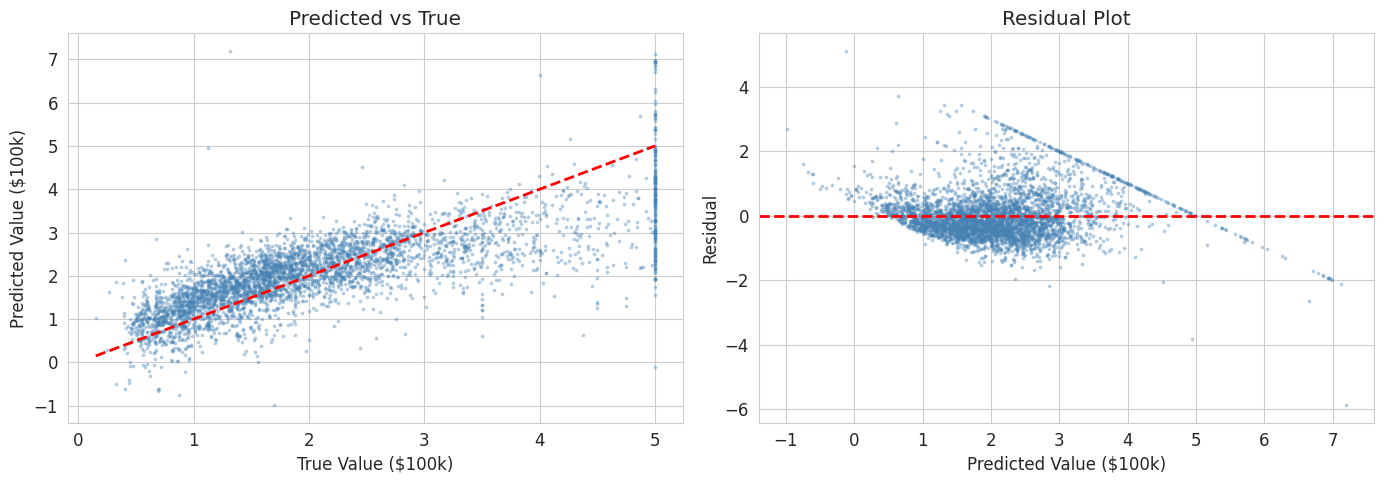

In [ ]:
# 预测值  真实值对比
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_test, y_pred_test, alpha=0.3, s=3, color='steelblue')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_xlabel('True Value ($100k)')
axes[0].set_ylabel('Predicted Value ($100k)')
axes[0].set_title('Predicted vs True')

residuals = y_test - y_pred_test
axes[1].scatter(y_pred_test, residuals, alpha=0.3, s=3, color='steelblue')
axes[1].axhline(0, color='r', ls='--', lw=2)
axes[1].set_xlabel('Predicted Value ($100k)')
axes[1].set_ylabel('Residual')
axes[1].set_title('Residual Plot')

plt.tight_layout()
plt.show()

## 6. 总结

闭式解（Normal Equation）通过公式 β = (XᵀX)⁻¹ Xᵀy 一步求出最优系数，优点是无需调参、收敛确定，但计算复杂度为 O(d³)，特征维度较高时计算开销较大。

本模型 Test R² 约为 0.59，说明基础线性回归存在欠拟合或过拟合风险——下一份 notebook 我们将引入 L2 正则化来解决。